# Tel Aviv dew point — ERA5-Land hourly, 1950 → 2026

First look at how 2 m dew point behaves over time, as raw hourly values and as daily min / mean / max.

**Data** — Open-Meteo historical archive, `models=era5_land`, `cell_selection=nearest`, at the product cell
**32.1°N 34.8°E** (`cells.csv` id 555, "Tel Aviv, Israel"; Open-Meteo answered for grid point 32.1, 34.800003, 7 m).
Pulled once by `pull_openmeteo_hourly.py` (8 requests, ~200 weighted Open-Meteo calls) and cached in `data/` —
re-running this notebook costs zero API calls.

**Local time** — timestamps arrive in UTC and are shifted by the cell's solar offset `round(lon / 15) = +2 h`,
the same DST-free rule `download_cells.py` uses to bucket the production archive into local days.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

DATA_FILE = Path("data/dew_point_2m_era5_land_32.1_34.8_hourly.csv.gz")
CELL_LAT, CELL_LON = 32.1, 34.8
SOLAR_OFFSET_HOURS = int(round(CELL_LON / 15))  # +2 h, DST-free, as in download_cells.py

raw = pd.read_csv(DATA_FILE, parse_dates=["time_utc"])
local_time = raw["time_utc"].dt.tz_convert(None) + pd.Timedelta(hours=SOLAR_OFFSET_HOURS)
hourly = pd.Series(raw["dew_point_2m"].to_numpy(), index=local_time, name="dew_point_C")

print(f"{len(hourly):,} hours, {hourly.index.min()} → {hourly.index.max()} (local solar time), "
      f"{hourly.isna().sum()} missing")
hourly.describe().round(2)

671,832 hours, 1950-01-01 02:00:00 → 2026-08-23 01:00:00 (local solar time), 1 missing


count    671831.00
mean         13.60
std           5.44
min         -15.70
25%           9.30
50%          13.50
75%          18.50
max          26.50
Name: dew_point_C, dtype: float64

In [2]:
# Plot style shared by every figure
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True, "grid.color": "#e5e5e5", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "center",
})
COLOR_HOURLY = "#2a2f3a"
COLOR_MAX, COLOR_MEAN, COLOR_MIN = "#eb6834", "#1baf7a", "#2a78d6"

last_hour = hourly.index.max()
WINDOWS = [
    ("Whole record, 1950 → 2026", hourly.index.min()),
    ("Last 10 years", last_hour - pd.DateOffset(years=10)),
    ("Last 1 year", last_hour - pd.DateOffset(years=1)),
]


def format_time_axis(axis, span_days):
    """Tick density that suits the window: decades, years, or months."""
    if span_days > 20 * 365:
        axis.xaxis.set_major_locator(mdates.YearLocator(10))
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    elif span_days > 2 * 365:
        axis.xaxis.set_major_locator(mdates.YearLocator(1))
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    else:
        axis.xaxis.set_major_locator(mdates.MonthLocator())
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))


def three_windows(figure_title, draw_panel):
    """One figure, three stacked panels (whole record / 10 y / 1 y); draw_panel(axis, window_start)."""
    figure, axes = plt.subplots(3, 1, figsize=(14, 11))
    for axis, (title, window_start) in zip(axes, WINDOWS):
        draw_panel(axis, window_start)
        axis.set_title(title)
        axis.set_ylabel("dew point (°C)")
        axis.set_xlim(window_start, last_hour)
        format_time_axis(axis, (last_hour - window_start).days)
    figure.suptitle(figure_title, fontsize=14)
    figure.tight_layout()
    return figure

## Hourly values

Every hour as one thin line. The whole-record panel is ~670k points, so it reads as the envelope of the
seasonal cycle; the shorter windows show the actual hour-to-hour behaviour.

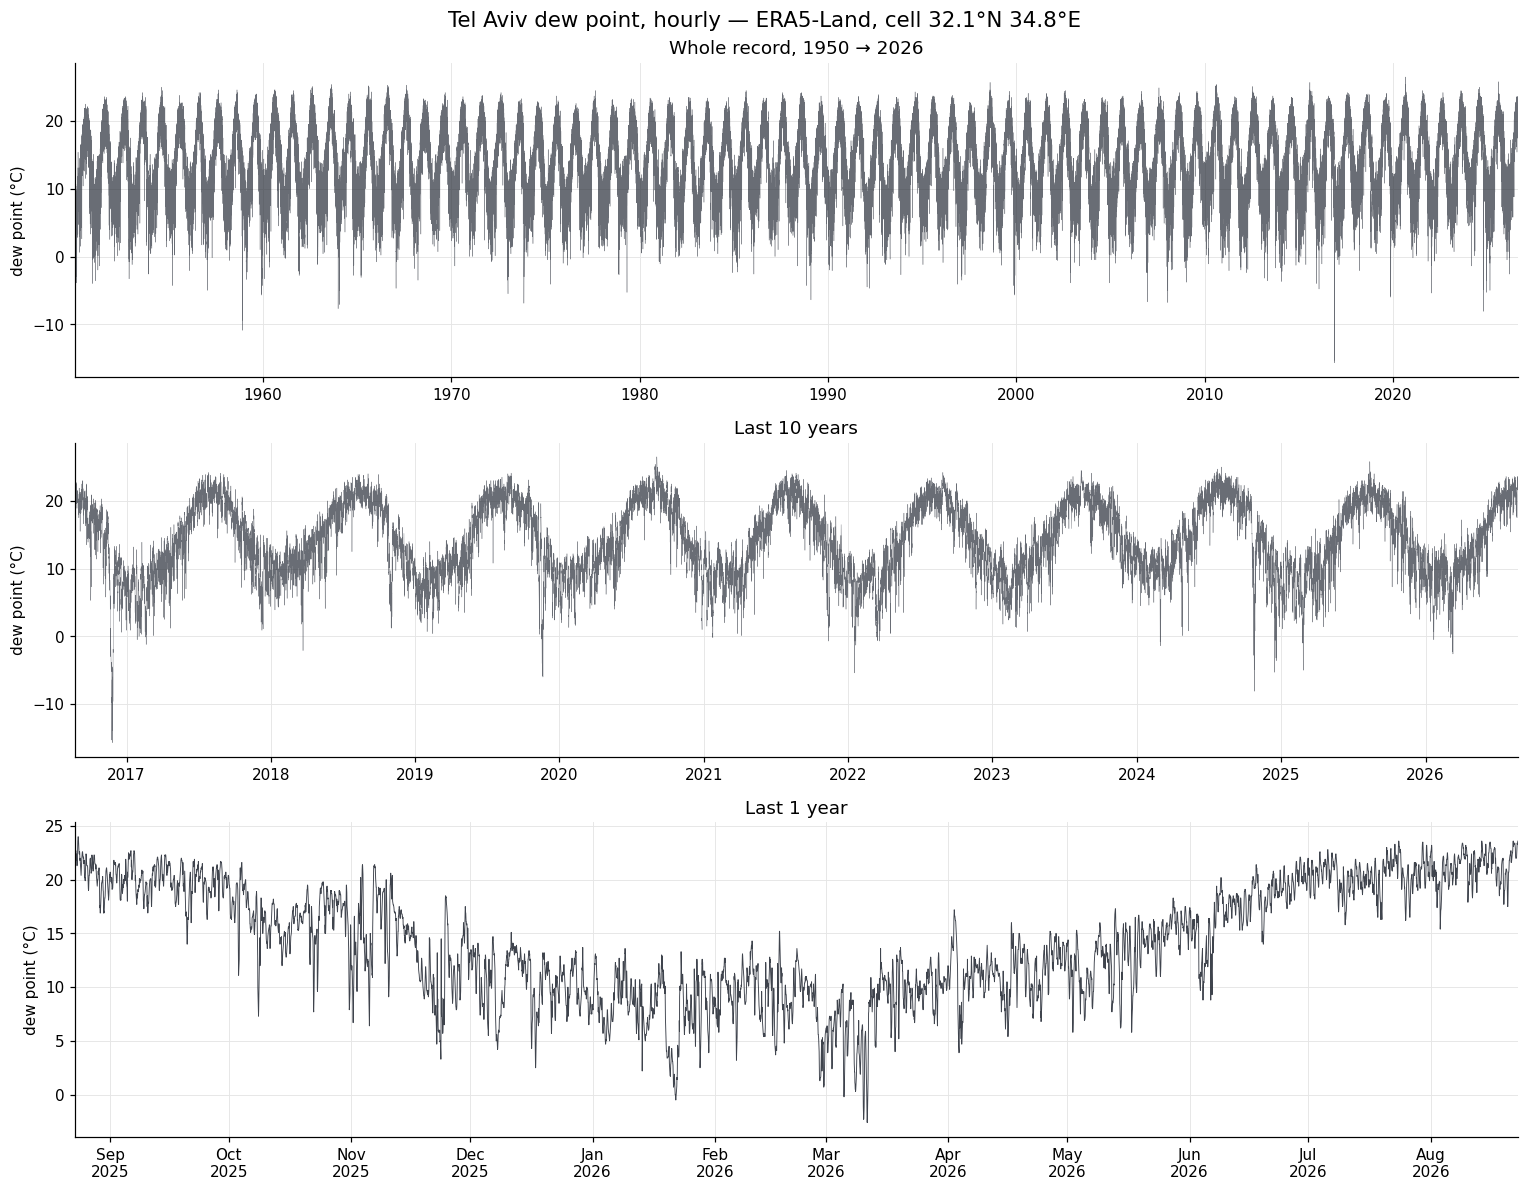

In [3]:
def draw_hourly(axis, window_start):
    window = hourly[window_start:]
    is_dense = len(window) > 50_000
    axis.plot(window.index, window.to_numpy(), color=COLOR_HOURLY,
              linewidth=0.25 if is_dense else 0.6, alpha=0.7 if is_dense else 0.9,
              rasterized=is_dense)


three_windows("Tel Aviv dew point, hourly — ERA5-Land, cell 32.1°N 34.8°E", draw_hourly);

## Daily min / mean / max

Bucketed by the cell's local solar day (00:00–23:00 at UTC+2); only days with all 24 hours present are kept,
the same whole-day rule as the production archive.

In [4]:
local_day = hourly.index.floor("D")
hours_present = hourly.groupby(local_day).count()
daily = hourly.groupby(local_day).agg(["min", "mean", "max"])
daily.columns = ["min", "mean", "max"]
whole_days = hours_present == 24
daily = daily[whole_days]

print(f"{len(daily):,} whole local days kept, {(~whole_days).sum()} partial day(s) dropped")
daily.describe().round(2)

27,992 whole local days kept, 2 partial day(s) dropped


,min,mean,max
count,27992.00,27992.00,27992.00
mean,11.59,13.60,15.61
std,5.61,5.25,5.04
min,-15.70,-11.45,-9.00
25%,7.20,9.32,11.40
50%,11.30,13.35,15.50
75%,16.70,18.48,20.30
max,23.90,24.73,26.50


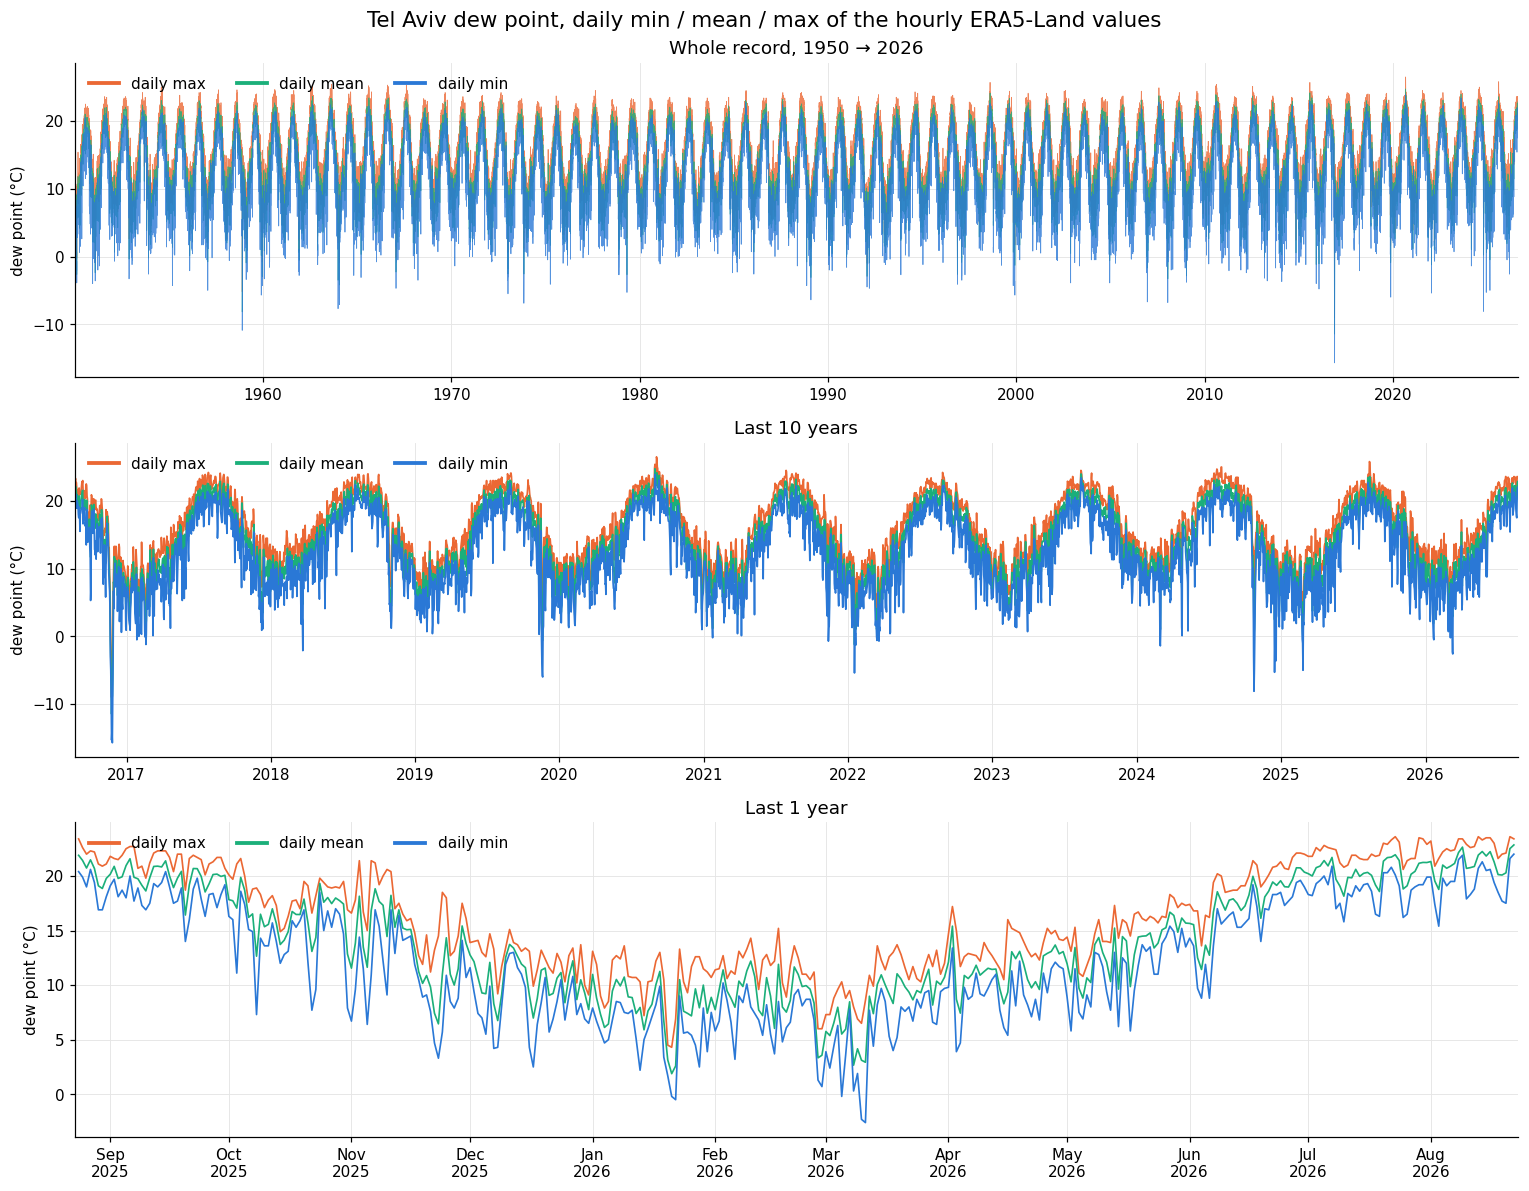

In [5]:
def draw_daily(axis, window_start):
    window = daily[window_start:]
    is_dense = len(window) > 5_000
    line_width = 0.5 if is_dense else 1.1
    for column, color, label in [("max", COLOR_MAX, "daily max"),
                                 ("mean", COLOR_MEAN, "daily mean"),
                                 ("min", COLOR_MIN, "daily min")]:
        axis.plot(window.index, window[column].to_numpy(), color=color, linewidth=line_width,
                  alpha=0.8 if is_dense else 1.0, label=label, rasterized=is_dense)
    legend = axis.legend(loc="upper left", ncol=3, frameon=False)
    for handle in legend.get_lines():   # legend swatches stay readable even when the data lines are hairlines
        handle.set_linewidth(2.5)
        handle.set_alpha(1.0)


three_windows("Tel Aviv dew point, daily min / mean / max of the hourly ERA5-Land values", draw_daily);

## Which daily aggregate says "how humid it felt"?

Three things decide it: **when** in the day the max/min happen (a 3 am max says nothing about a muggy afternoon),
**how far apart** the aggregates are (if the whole day sits within 3 °C the choice hardly matters), and — since the
product shows a day as a percentile of its own history — **how often the choice flips a day's rank**.

JJA: max dew point falls between 18:00 and 05:00 on 96% of days; never between 12:00 and 17:00 (0.2%).
JJA: max − mean median 1.7 °C, max − min median 3.2 °C.
JJA: choosing max instead of mean moves a day's percentile by >20 points on 11% of days (median shift 7 points).
Spike check: hourly max exceeds the max of a 3-hour running mean by >1 °C on 0.8% of days — the max is an air-mass value, not a one-hour blip.


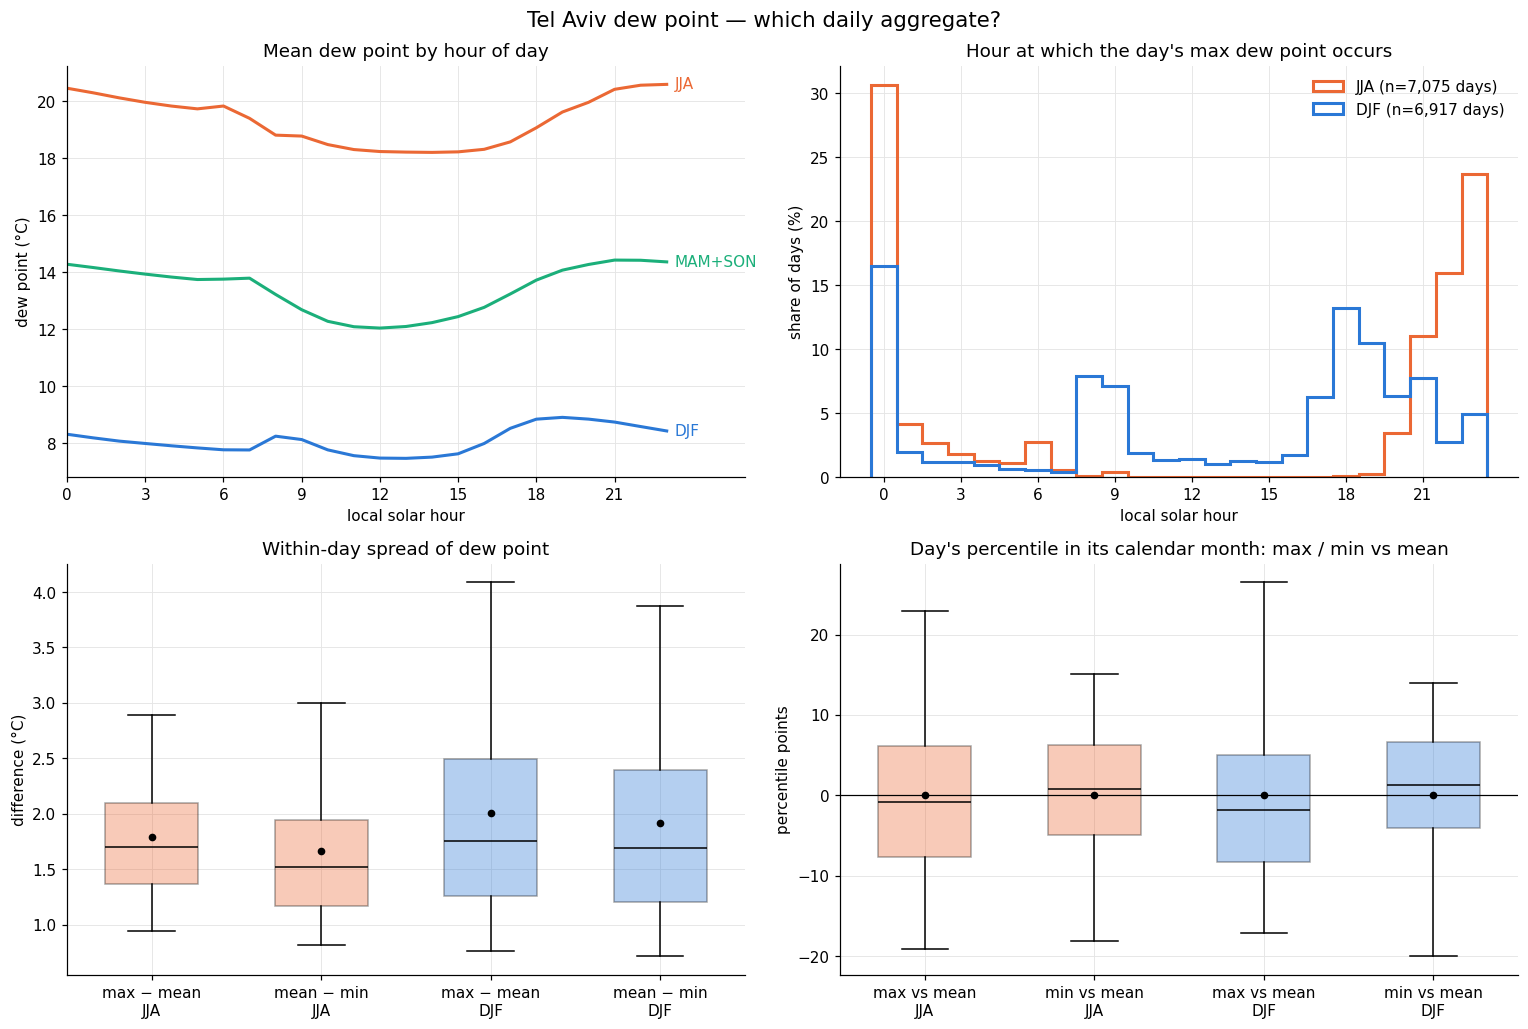

In [6]:
import numpy as np

hourly_by_day = hourly.groupby(hourly.index.floor("D"))
daily["hour_of_max"] = hourly_by_day.idxmax().dt.hour.reindex(daily.index)
daily["hour_of_min"] = hourly_by_day.idxmin().dt.hour.reindex(daily.index)

month = daily.index.month
season = pd.Series(np.where(month.isin([6, 7, 8]), "JJA",
                   np.where(month.isin([12, 1, 2]), "DJF", "MAM+SON")), index=daily.index)
SEASON_COLORS = {"JJA": COLOR_MAX, "DJF": COLOR_MIN, "MAM+SON": COLOR_MEAN}

# A day's percentile within its calendar month's climatology, under each aggregate
for column in ["max", "mean", "min"]:
    daily[f"pct_{column}"] = daily.groupby(month)[column].rank(pct=True) * 100

BOX_STYLE = dict(whis=(5, 95), showfliers=False, showmeans=True, widths=0.55, patch_artist=True,
                 meanprops=dict(marker="o", markerfacecolor="black", markeredgecolor="black", markersize=4),
                 medianprops=dict(color="black"))


def tinted_boxplot(axis, data, labels, colors, y_label, title):
    """Boxplot (median/IQR, 5–95 whiskers, mean as a dot) with one season tint per box."""
    boxes = axis.boxplot(data, **BOX_STYLE)
    for patch, color in zip(boxes["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    axis.set_xticks(range(1, len(labels) + 1), labels)
    axis.set_ylabel(y_label)
    axis.set_title(title)


figure, axes = plt.subplots(2, 2, figsize=(14, 9.5))

# A — diurnal cycle per season
axis = axes[0, 0]
hour_of_day = hourly.index.hour
season_of_hour = season.reindex(hourly.index.floor("D")).to_numpy()
for name, color in SEASON_COLORS.items():
    in_season = season_of_hour == name
    cycle = hourly[in_season].groupby(hour_of_day[in_season]).mean()
    axis.plot(cycle.index, cycle.to_numpy(), color=color, linewidth=2)
    axis.annotate(name, (23, cycle.iloc[-1]), xytext=(5, 0), textcoords="offset points", color=color, va="center")
axis.set_xticks(range(0, 24, 3))
axis.set_xlim(0, 26)
axis.set_xlabel("local solar hour")
axis.set_ylabel("dew point (°C)")
axis.set_title("Mean dew point by hour of day")

# B — when does the day's max happen?
axis = axes[0, 1]
for name in ["JJA", "DJF"]:
    hours = daily.loc[season == name, "hour_of_max"]
    axis.hist(hours, bins=np.arange(-0.5, 24.5, 1), weights=np.full(len(hours), 100 / len(hours)),
              histtype="step", linewidth=2, color=SEASON_COLORS[name], label=f"{name} (n={len(hours):,} days)")
axis.set_xticks(range(0, 24, 3))
axis.set_xlabel("local solar hour")
axis.set_ylabel("share of days (%)")
axis.set_title("Hour at which the day's max dew point occurs")
axis.legend(frameon=False)

# C — within-day spread
spread_data, spread_labels, spread_colors = [], [], []
for name in ["JJA", "DJF"]:
    in_season = daily[season == name]
    for high, low in [("max", "mean"), ("mean", "min")]:
        spread_data.append((in_season[high] - in_season[low]).to_numpy())
        spread_labels.append(f"{high} − {low}\n{name}")
        spread_colors.append(SEASON_COLORS[name])
tinted_boxplot(axes[1, 0], spread_data, spread_labels, spread_colors,
               "difference (°C)", "Within-day spread of dew point")

# D — does the choice move a day's percentile?
rank_data, rank_labels, rank_colors = [], [], []
for name in ["JJA", "DJF"]:
    in_season = daily[season == name]
    for other in ["max", "min"]:
        rank_data.append((in_season[f"pct_{other}"] - in_season["pct_mean"]).to_numpy())
        rank_labels.append(f"{other} vs mean\n{name}")
        rank_colors.append(SEASON_COLORS[name])
tinted_boxplot(axes[1, 1], rank_data, rank_labels, rank_colors,
               "percentile points", "Day's percentile in its calendar month: max / min vs mean")
axes[1, 1].axhline(0, color="black", linewidth=0.8)

figure.suptitle("Tel Aviv dew point — which daily aggregate?", fontsize=14)
figure.tight_layout()

summer = daily[season == "JJA"]
night_max = summer["hour_of_max"].between(18, 23) | summer["hour_of_max"].between(0, 5)
rank_shift = (summer["pct_max"] - summer["pct_mean"]).abs()
print(f"JJA: max dew point falls between 18:00 and 05:00 on {night_max.mean() * 100:.0f}% of days; "
      f"never between 12:00 and 17:00 ({summer['hour_of_max'].between(12, 17).mean() * 100:.1f}%).")
print(f"JJA: max − mean median {(summer['max'] - summer['mean']).median():.1f} °C, max − min median "
      f"{(summer['max'] - summer['min']).median():.1f} °C.")
print(f"JJA: choosing max instead of mean moves a day's percentile by >20 points on "
      f"{(rank_shift > 20).mean() * 100:.0f}% of days (median shift {rank_shift.median():.0f} points).")
print(f"Spike check: hourly max exceeds the max of a 3-hour running mean by >1 °C on "
      f"{((daily['max'] - hourly.rolling(3, center=True).mean().groupby(hourly.index.floor('D')).max().reindex(daily.index)) > 1).mean() * 100:.1f}% of days "
      f"— the max is an air-mass value, not a one-hour blip.")

### Reading

- Tel Aviv's dew point is **lowest in the afternoon and highest at night**: daytime mixing dries the surface air,
  the evening/night restores it. So the daily **max is a night-time number** (≈96 % of summer days between 18:00 and
  05:00, essentially never 12–17) — it measures the sticky-night feel, not the muggy-afternoon feel.
- The three aggregates sit within ~3 °C of each other, and the max is not a spike artefact — dew point is a property
  of the air mass and moves slowly.
- Because the spread is small, the aggregates rank days almost identically (Spearman ≈ 0.95 mean–max in summer),
  but not identically: swapping max for mean moves ~1 day in 10 by more than 20 percentile points.
- **Recommendation: daily mean** as the headline "how humid was the day" — it is the robust air-mass value, ranks days
  the same way a daytime-only mean does (median 3-point difference), and does not depend on a 2 am reading. The max is
  the honest answer to a different question ("how sticky was the night"); the min answers "how dry did it get".
  How it *felt* in the heat is a joint temperature × dew point quantity (heat index / humidex at the warm hours),
  which belongs to the perceived-temperature work, not to the dew-point card.
- One coastal cell: inland/desert cells have a much larger diurnal dew-point cycle, so max vs mean will diverge more
  there, and the max will be even more of a night/morning value.

## Other cities: does this hold inland, in a desert, and at the equator?

Three contrasting product cells, 10 years each (2016-08-23 → 2026-08-22, ~26 weighted Open-Meteo calls per city,
same `pull_openmeteo_hourly.py`, cached in `data/`): **Jerusalem** (31.8, 35.2 — hills, 800 m), **Phoenix**
(33.5, −112.0 — desert), **Singapore** (1.3, 103.8 — equatorial). Tel Aviv is cut to the same 10-year window.
Each city is shifted to its own solar local clock (`round(lon / 15)`: +2, +2, −7, +7 h).

In [7]:
CITIES = {
    "Tel Aviv (32.1, 34.8)": (32.1, 34.8),
    "Jerusalem (31.8, 35.2)": (31.8, 35.2),
    "Phoenix (33.5, -112.0)": (33.5, -112.0),
    "Singapore (1.3, 103.8)": (1.3, 103.8),
}
COMPARE_START = pd.Timestamp("2016-08-23")   # the window the extra cities were pulled for


def load_hourly(lat, lon):
    """Hourly dew point at a product cell, indexed by the cell's solar-local time."""
    frame = pd.read_csv(Path(f"data/dew_point_2m_era5_land_{lat}_{lon}_hourly.csv.gz"), parse_dates=["time_utc"])
    offset_hours = int(round(lon / 15))
    local_time = frame["time_utc"].dt.tz_convert(None) + pd.Timedelta(hours=offset_hours)
    return pd.Series(frame["dew_point_2m"].to_numpy(), index=local_time, name="dew_point_C")


def daily_aggregates(hourly_series):
    """Whole-local-day min / mean / max / daytime mean, hour of the max, season, and each day's
    percentile within its calendar month under each aggregate."""
    valid = hourly_series.dropna()
    by_day = valid.groupby(valid.index.floor("D"))
    daytime = valid[valid.index.hour.isin(range(8, 23))]
    frame = pd.DataFrame({
        "min": by_day.min(), "mean": by_day.mean(), "max": by_day.max(),
        "daytime_mean": daytime.groupby(daytime.index.floor("D")).mean(),
        "hour_of_max": by_day.idxmax().dt.hour,
    })
    frame = frame[by_day.count() == 24]
    month = frame.index.month
    frame["season"] = np.where(month.isin([6, 7, 8]), "JJA", np.where(month.isin([12, 1, 2]), "DJF", "MAM+SON"))
    for column in ["max", "mean", "min", "daytime_mean"]:
        frame[f"pct_{column}"] = frame.groupby(month)[column].rank(pct=True) * 100
    return frame


city_hourly = {name: load_hourly(lat, lon)[COMPARE_START:] for name, (lat, lon) in CITIES.items()}
city_daily = {name: daily_aggregates(series) for name, series in city_hourly.items()}

summary_rows = []
for name, frame in city_daily.items():
    summer = frame[frame["season"] == "JJA"]
    max_at_night = summer["hour_of_max"].between(18, 23) | summer["hour_of_max"].between(0, 5)
    shift_all = (frame["pct_max"] - frame["pct_mean"]).abs()
    shift_daytime = (frame["pct_daytime_mean"] - frame["pct_mean"]).abs()
    summary_rows.append({
        "city": name,
        "whole days": len(frame),
        "JJA max at 18–05 h (% of days)": max_at_night.mean() * 100,
        "JJA max at 12–17 h (% of days)": summer["hour_of_max"].between(12, 17).mean() * 100,
        "JJA max − mean (°C, median)": (summer["max"] - summer["mean"]).median(),
        "JJA max − min (°C, median)": (summer["max"] - summer["min"]).median(),
        "Spearman mean–max (all days)": frame["mean"].corr(frame["max"], method="spearman"),
        "|pct max − pct mean| > 20 (% of days)": (shift_all > 20).mean() * 100,
        "|pct daytime-mean − pct mean| > 20 (% of days)": (shift_daytime > 20).mean() * 100,
    })
pd.DataFrame(summary_rows).set_index("city").round(2).T

city,"Tel Aviv (32.1, 34.8)","Jerusalem (31.8, 35.2)","Phoenix (33.5, -112.0)","Singapore (1.3, 103.8)"
whole days,3652.00,3651.00,3651.00,3651.00
JJA max at 18–05 h (% of days),94.57,87.38,53.10,25.14
JJA max at 12–17 h (% of days),0.65,0.54,7.18,52.45
"JJA max − mean (°C, median)",1.56,2.64,3.23,0.59
"JJA max − min (°C, median)",3.00,5.90,6.70,1.20
Spearman mean–max (all days),0.98,0.96,0.97,0.92
|pct max − pct mean| > 20 (% of days),12.98,16.95,4.79,11.91
|pct daytime-mean − pct mean| > 20 (% of days),1.42,3.42,0.47,1.45


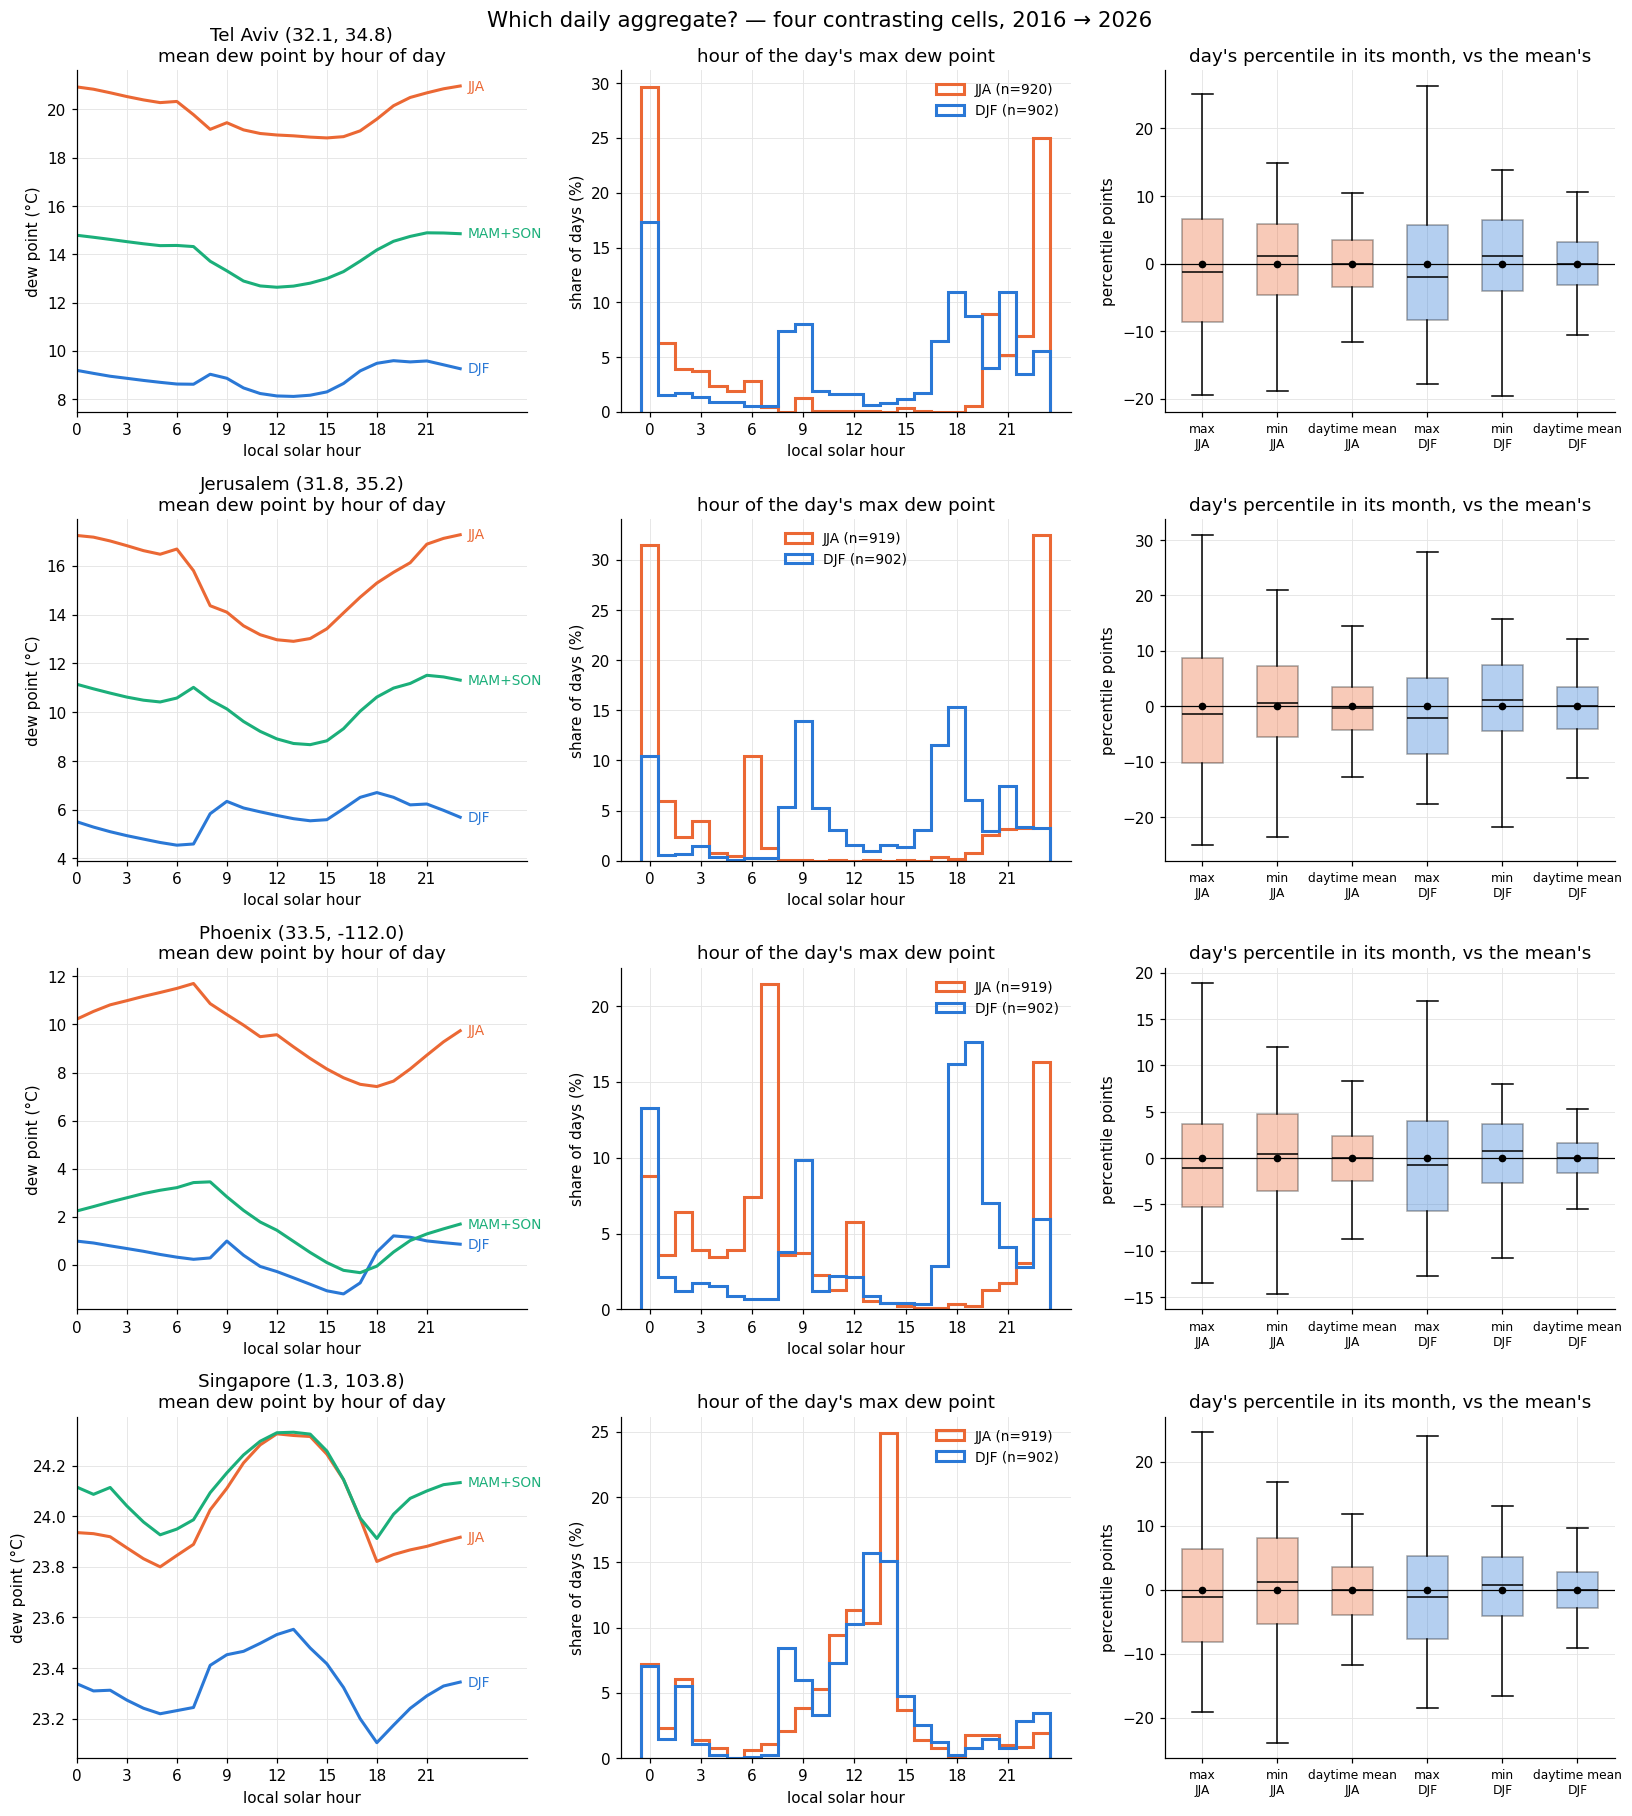

In [8]:
figure, axes = plt.subplots(len(CITIES), 3, figsize=(15, 4.2 * len(CITIES)))
for row, (name, frame) in zip(axes, city_daily.items()):
    hourly_series = city_hourly[name]
    hour_of_day = hourly_series.index.hour
    season_of_hour = frame["season"].reindex(hourly_series.index.floor("D")).to_numpy()

    # diurnal cycle per season
    axis = row[0]
    for season_name, color in SEASON_COLORS.items():
        in_season = season_of_hour == season_name
        cycle = hourly_series[in_season].groupby(hour_of_day[in_season]).mean()
        axis.plot(cycle.index, cycle.to_numpy(), color=color, linewidth=2)
        axis.annotate(season_name, (23, cycle.iloc[-1]), xytext=(5, 0), textcoords="offset points",
                      color=color, va="center", fontsize=9)
    axis.set_xticks(range(0, 24, 3))
    axis.set_xlim(0, 27)
    axis.set_xlabel("local solar hour")
    axis.set_ylabel("dew point (°C)")
    axis.set_title(f"{name}\nmean dew point by hour of day")

    # hour of the day's max
    axis = row[1]
    for season_name in ["JJA", "DJF"]:
        hours = frame.loc[frame["season"] == season_name, "hour_of_max"]
        axis.hist(hours, bins=np.arange(-0.5, 24.5, 1), weights=np.full(len(hours), 100 / len(hours)),
                  histtype="step", linewidth=2, color=SEASON_COLORS[season_name],
                  label=f"{season_name} (n={len(hours):,})")
    axis.set_xticks(range(0, 24, 3))
    axis.set_xlabel("local solar hour")
    axis.set_ylabel("share of days (%)")
    axis.set_title("hour of the day's max dew point")
    axis.legend(frameon=False, fontsize=9)

    # rank shift vs the mean
    rank_data, rank_labels, rank_colors = [], [], []
    for season_name in ["JJA", "DJF"]:
        in_season = frame[frame["season"] == season_name]
        for other in ["max", "min", "daytime_mean"]:
            rank_data.append((in_season[f"pct_{other}"] - in_season["pct_mean"]).to_numpy())
            rank_labels.append(f"{other.replace('_', ' ')}\n{season_name}")
            rank_colors.append(SEASON_COLORS[season_name])
    tinted_boxplot(row[2], rank_data, rank_labels, rank_colors,
                   "percentile points", "day's percentile in its month, vs the mean's")
    row[2].axhline(0, color="black", linewidth=0.8)
    row[2].tick_params(axis="x", labelsize=8)

figure.suptitle("Which daily aggregate? — four contrasting cells, 2016 → 2026", fontsize=14)
figure.tight_layout()

### The last month, hourly plus every aggregate

Thin grey = hourly; one horizontal segment per local day for each aggregate.

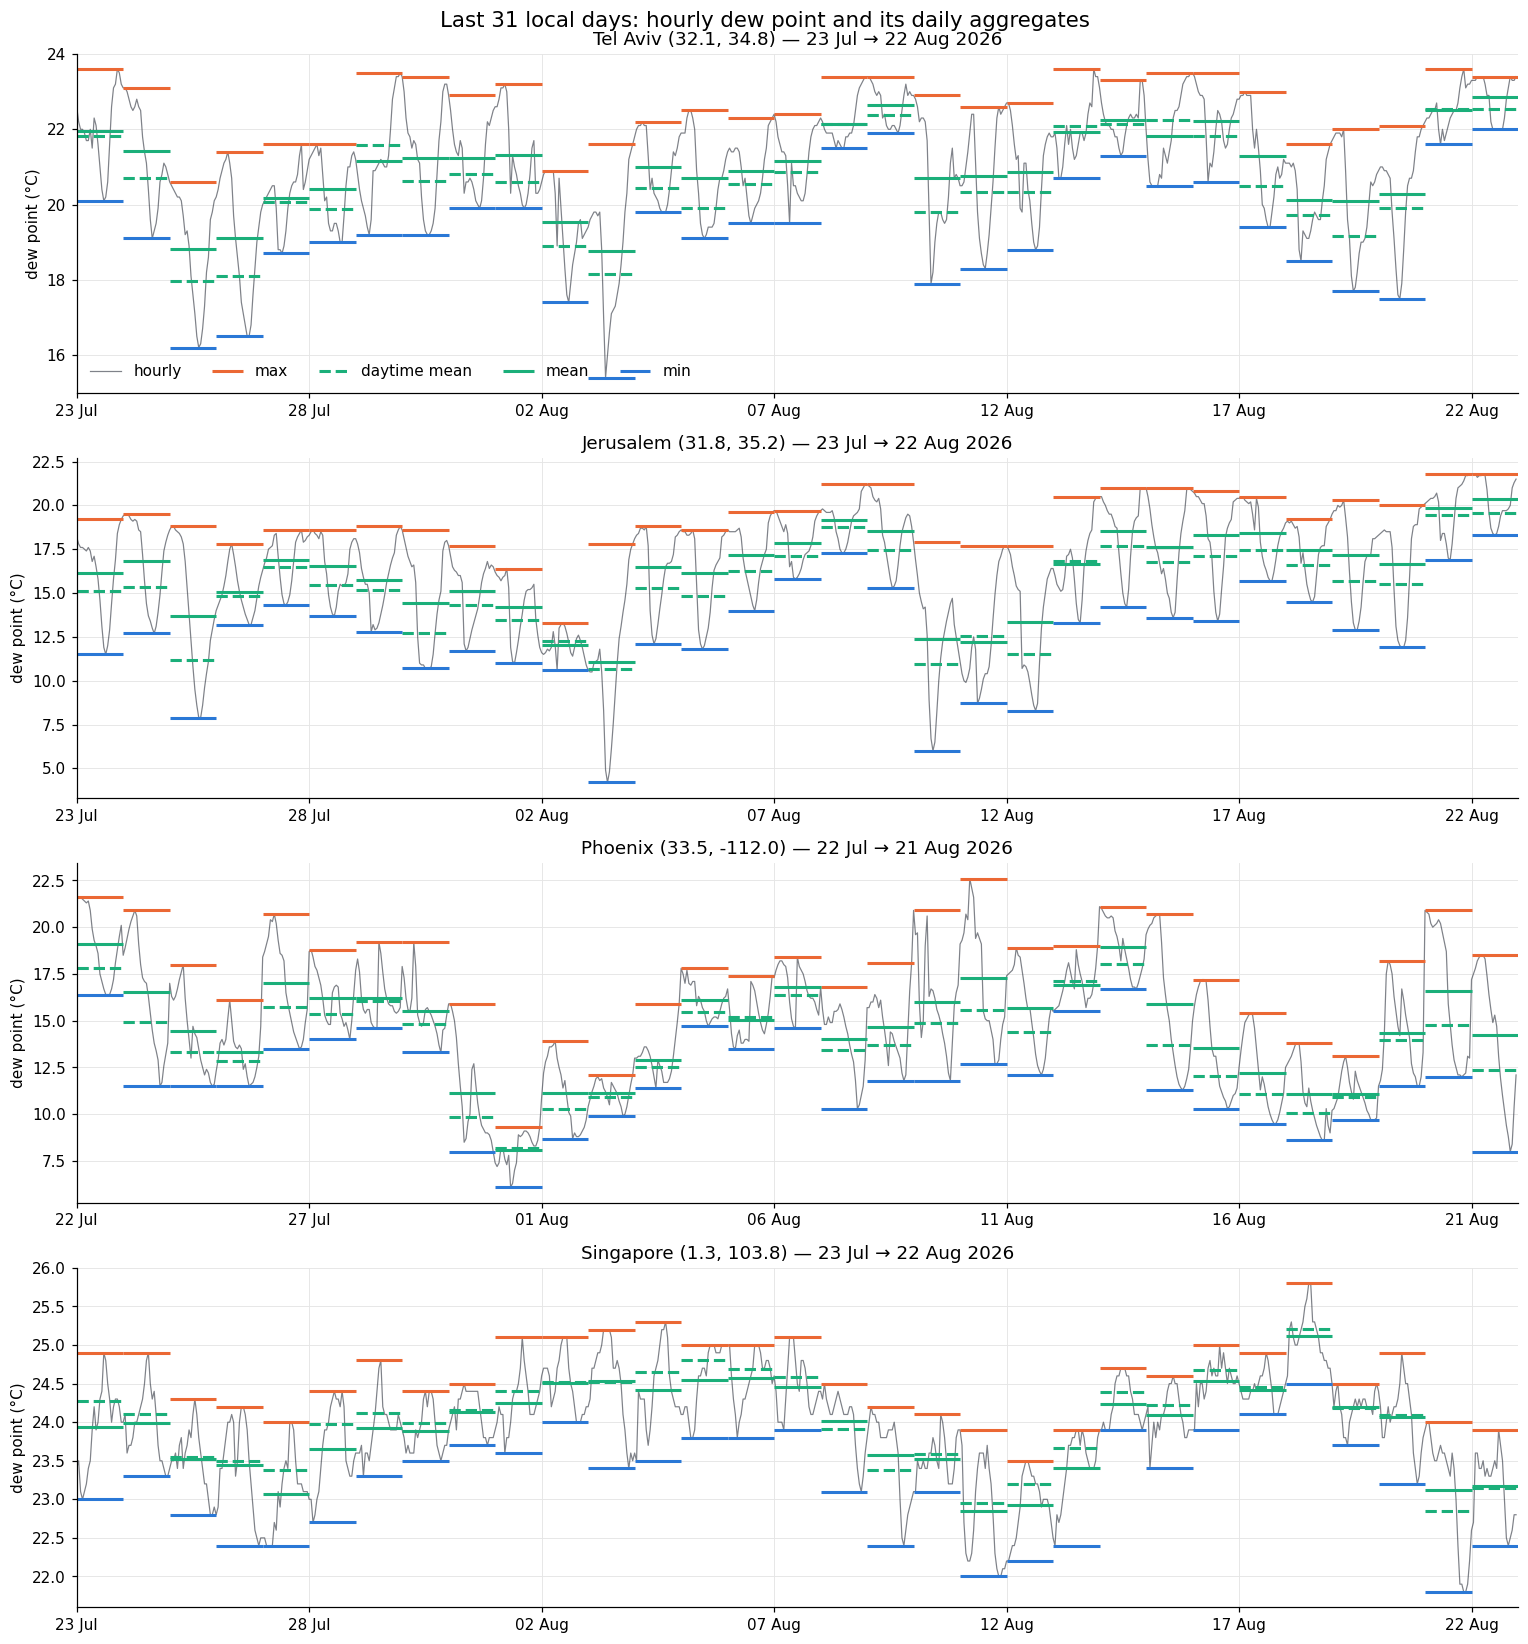

In [9]:
figure, axes = plt.subplots(len(CITIES), 1, figsize=(14, 3.8 * len(CITIES)))
AGGREGATE_STYLE = [("max", COLOR_MAX, "-"), ("daytime_mean", COLOR_MEAN, "--"),
                   ("mean", COLOR_MEAN, "-"), ("min", COLOR_MIN, "-")]
for axis, (name, frame) in zip(axes, city_daily.items()):
    last_day = frame.index.max()
    window_start = last_day - pd.Timedelta(days=30)
    hourly_window = city_hourly[name][window_start:last_day + pd.Timedelta(hours=23)]
    daily_window = frame[window_start:]
    axis.plot(hourly_window.index, hourly_window.to_numpy(), color=COLOR_HOURLY, linewidth=0.8, alpha=0.6,
              label="hourly")
    for column, color, style in AGGREGATE_STYLE:
        axis.hlines(daily_window[column], daily_window.index, daily_window.index + pd.Timedelta(days=1),
                    color=color, linewidth=2, linestyle=style, label=column.replace("_", " "))
    axis.set_title(f"{name} — {window_start:%d %b} → {last_day:%d %b %Y}")
    axis.set_ylabel("dew point (°C)")
    axis.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axis.set_xlim(window_start, last_day + pd.Timedelta(days=1))
axes[0].legend(loc="lower left", ncol=5, frameon=False)
figure.suptitle("Last 31 local days: hourly dew point and its daily aggregates", fontsize=14)
figure.tight_layout()

### How much does each aggregate discriminate between summer days?

If an aggregate is pinned to a physical ceiling (the marine air's dew point in Tel Aviv, saturation at the equator),
it bunches up and stops telling days apart — its percentile becomes a coin flip. The interquartile range of each
aggregate across JJA days, per city:

In [10]:
discrimination = pd.DataFrame({
    name: {column: frame.loc[frame["season"] == "JJA", column].quantile(0.75)
                   - frame.loc[frame["season"] == "JJA", column].quantile(0.25)
           for column in ["max", "daytime_mean", "mean", "min"]}
    for name, frame in city_daily.items()
}).T
discrimination.columns = [f"IQR of daily {c.replace('_', ' ')} across JJA days (°C)" for c in discrimination.columns]
discrimination.round(2)

,IQR of daily max across JJA days (°C),IQR of daily daytime mean across JJA days (°C),IQR of daily mean across JJA days (°C),IQR of daily min across JJA days (°C)
"Tel Aviv (32.1, 34.8)",2.22,2.65,2.44,2.80
"Jerusalem (31.8, 35.2)",3.00,3.46,3.47,4.10
"Phoenix (33.5, -112.0)",13.15,12.41,12.87,13.05
"Singapore (1.3, 103.8)",0.70,0.77,0.70,0.80


### Reading across the four cells

- **The timing of the max is a local accident, not a "felt" moment.** Tel Aviv and Jerusalem: night (95 % / 87 % of
  summer days between 18:00 and 05:00). Phoenix: dawn (a 07 h spike) plus night — the afternoon dries out by 4 °C.
  Singapore: the opposite, the max sits at 12–15 h (52 %) because there is no dry-out and the day heats the swamp.
  A "daily max dew point" therefore means a different time of day in every city, and never reliably the hot hours.
- **Spread within a day scales with continentality**: max − min median 3.0 °C (Tel Aviv), 5.9 °C (Jerusalem),
  6.7 °C (Phoenix), 1.2 °C (Singapore). The choice matters more inland — and inland the max is a dawn/night value.
- **Rank stability.** Max vs mean moves a day's month-percentile by >20 points on 13 % / 17 % / 5 % / 12 % of days
  (Tel Aviv / Jerusalem / Phoenix / Singapore). Daytime mean vs mean: 1.4 % / 3.4 % / 0.5 % / 1.5 % — the plain
  mean already *is* the daytime story everywhere, including the desert where the two levels differ by 1–2 °C.
- **Discrimination.** Across summer days the max has the narrowest IQR of the aggregates in the two Israeli cells
  (2.2 vs 2.4 mean vs 2.8 min °C in Tel Aviv; 3.0 vs 3.5 vs 4.1 in Jerusalem): it bunches against the marine
  ceiling, so it tells days apart slightly worse than the mean. Phoenix (IQR ≈ 13 °C for all, monsoon vs dry) and
  Singapore (≈ 0.7 °C for all) show no difference.
- **Last-month view.** The mean moves smoothly day to day and sits on top of the daytime mean; the max hugs the
  ceiling and repeats the same value across very different days (Tel Aviv 9–17 Aug, Singapore 5–8 Aug); the min
  is the volatile one, swinging 3–5 °C on single dry-air intrusions.

**Conclusion unchanged, now with four cells behind it: ship the daily mean.** Keep the max/min as the day's
range if the card wants a second line ("air was 19–23 °C dew point"), but the number that gets a percentile and a
word should be the mean.